<a href="https://colab.research.google.com/github/ShahbazShaikh96/sshaikh7_AdvanceMachineLearning/blob/main/Shahbaz_Assignment3_TimeSeries_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: Time-Series Forecasting with RNNs
**Dataset:** Jena Climate Dataset (2009–2016)  
**Goal:** Forecast temperature 24 hours ahead using five deep-learning architectures and identify the best model via validation MAE, then evaluate it on the test set.

## 1. Imports & Setup

In [3]:
!pip install tensorflow

In [4]:
import os, random, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## 2. Load the Jena Climate Dataset

The **Jena Climate dataset** was recorded at the Max Planck Institute for Biogeochemistry in Jena, Germany.
It contains 14 atmospheric measurements (temperature, pressure, humidity, wind speed, etc.)
sampled every 10 minutes from January 2009 to December 2016 — roughly 420,000 rows.

This is the canonical dataset used in *Deep Learning with Python* (Chollet) and *Deep Learning with R*
for time-series forecasting exercises. The cell below downloads it automatically via Keras.

In [6]:
path = keras.utils.get_file(
    fname="jena_climate_2009_2016.csv.zip",
    origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
    extract=True,
    cache_dir=".",
    cache_subdir="data"
)
# The 'path' variable now holds the path to the extracted directory, e.g., './data/jena_climate_2009_2016_extracted'
# So, we join 'path' directly with the CSV filename to get the correct full path.
csv_path = os.path.join(path, "jena_climate_2009_2016.csv")

df = pd.read_csv(csv_path)
print(f"Dataset shape: {df.shape}")
print(f"Date range:    {df['Date Time'].iloc[0]}  →  {df['Date Time'].iloc[-1]}")
df.head(3)

Dataset shape: (420551, 15)
Date range:    01.01.2009 00:10:00  →  01.01.2017 00:00:00


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6


## 3. Exploratory Data Analysis

Before building any model it is essential to understand the target variable.
Temperature (°C) shows a clear annual seasonal cycle — warmer summers and colder winters —
as well as daily fluctuations. These patterns are exactly what the RNNs will learn to exploit.

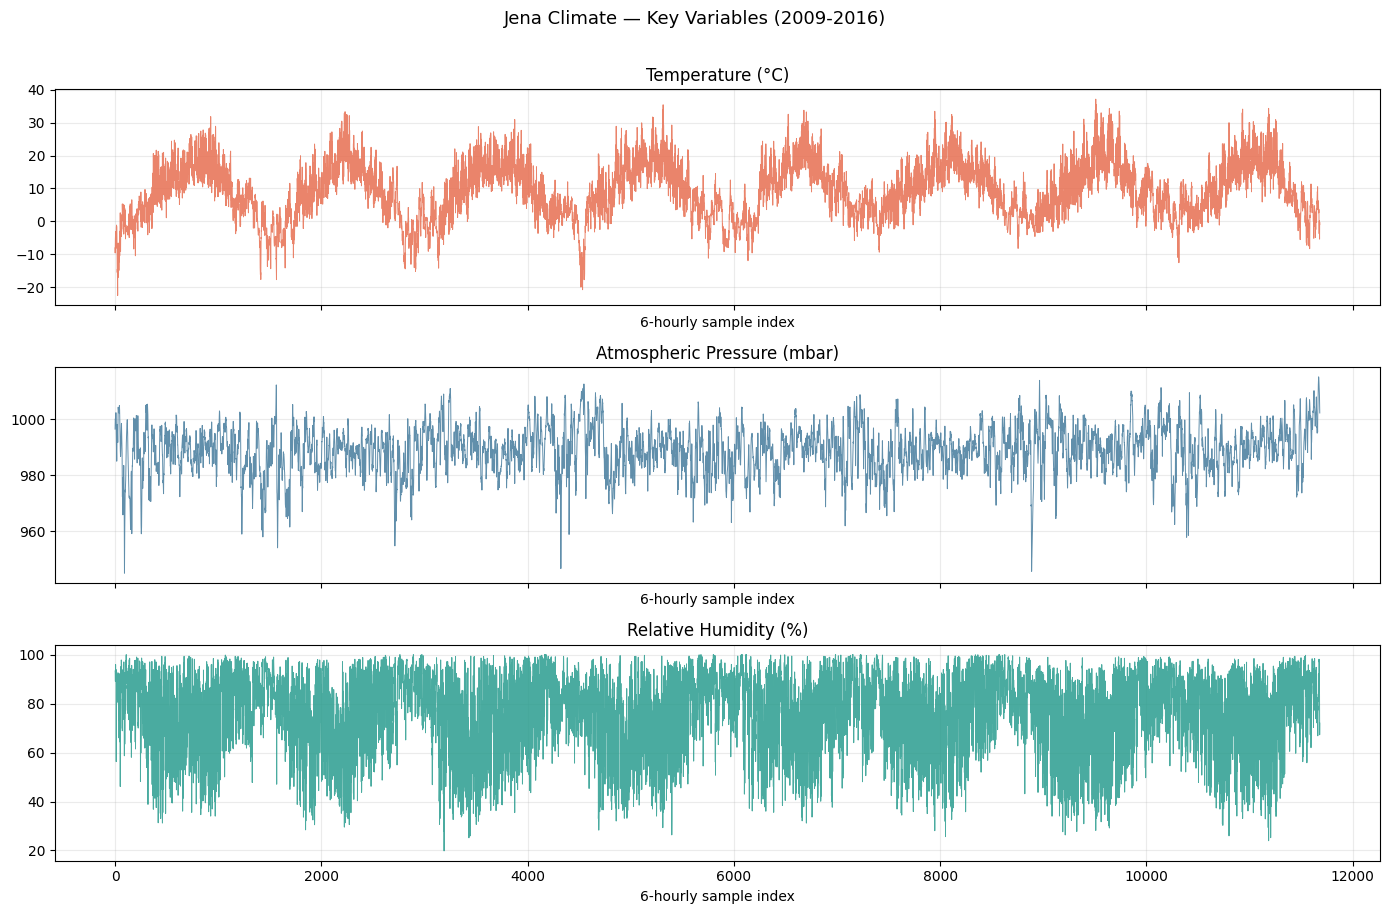


Descriptive statistics:


,mean,std,min,max
p (mbar),989.21,8.36,913.60,1015.35
T (degC),9.45,8.42,-23.01,37.28
Tpot (K),283.49,8.50,250.60,311.34
Tdew (degC),4.96,6.73,-25.01,23.11
rh (%),76.01,16.48,12.95,100.00
VPmax (mbar),13.58,7.74,0.95,63.77
VPact (mbar),9.53,4.18,0.79,28.32
VPdef (mbar),4.04,4.90,0.00,46.01
sh (g/kg),6.02,2.66,0.50,18.13
H2OC (mmol/mol),9.64,4.24,0.80,28.82


In [7]:
# Sample at 6-hour intervals for legible plots
sample = df.iloc[::36]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(sample["T (degC)"].values,  color="#E76F51", lw=0.7, alpha=0.85)
axes[0].set_title("Temperature (°C)")

axes[1].plot(sample["p (mbar)"].values,  color="#457B9D", lw=0.7, alpha=0.85)
axes[1].set_title("Atmospheric Pressure (mbar)")

axes[2].plot(sample["rh (%)"].values,    color="#2A9D8F", lw=0.7, alpha=0.85)
axes[2].set_title("Relative Humidity (%)")

for ax in axes:
    ax.grid(alpha=0.25)
    ax.set_xlabel("6-hourly sample index")

plt.suptitle("Jena Climate — Key Variables (2009-2016)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\nDescriptive statistics:")
df.describe().T[["mean", "std", "min", "max"]].round(2)

## 4. Data Preprocessing

Three decisions here are critical for correctness:

1. **Chronological split** — we never shuffle the data before splitting; the future must not leak into training.  
2. **Normalise with training statistics only** — applying the training mean/std to val and test prevents data leakage.  
3. **Subsampling** — the raw frequency is 10 minutes; we step every 6 rows (1-hour intervals) for the sequence windows to keep training feasible.

| Split | Rows | Share |
|-------|------|-------|
| Train | first 70% | Jan 2009 – ~Jul 2014 |
| Val   | next 15%  | ~Jul 2014 – ~Oct 2015 |
| Test  | last 15%  | ~Oct 2015 – Dec 2016 |

In [8]:
# Drop the date column; keep all 14 numeric features
features = df.columns[1:]
data = df[features].values.astype("float32")

TARGET_COL = list(features).index("T (degC)")   # column index of temperature
print(f"Target column index: {TARGET_COL}  →  '{features[TARGET_COL]}'")

# Chronological split
n = len(data)
num_train = int(n * 0.70)
num_val   = int(n * 0.15)

train_data = data[:num_train]
val_data   = data[num_train : num_train + num_val]
test_data  = data[num_train + num_val :]

print(f"\nSplit sizes  →  Train: {len(train_data):,}  |  Val: {len(val_data):,}  |  Test: {len(test_data):,}")

# Normalise using TRAINING statistics only
mean = train_data.mean(axis=0)
std  = train_data.std(axis=0)

train_data = (train_data - mean) / std
val_data   = (val_data   - mean) / std
test_data  = (test_data  - mean) / std

print("Normalisation complete. Sample mean of training temperature:", round(train_data[:, TARGET_COL].mean(), 4))

Target column index: 1  →  'T (degC)'

Split sizes  →  Train: 294,385  |  Val: 63,082  |  Test: 63,084
Normalisation complete. Sample mean of training temperature: -0.0


## 5. Sequence Dataset Construction

We use `keras.utils.timeseries_dataset_from_array` to build sliding-window (sequence → label) pairs.

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `LOOKBACK` | 720 | Use 5 days of past observations (720 × 10 min) |
| `STEP`     | 6   | Sample one point per hour (6 × 10 min) → 120 timesteps per window |
| `DELAY`    | 144 | Predict 24 hours into the future (144 × 10 min) |
| `BATCH_SIZE` | 256 | Mini-batch size |

Each sample fed to the model has shape **(120 timesteps × 14 features)**.

In [9]:
LOOKBACK    = 720    # 5 days of 10-min observations
STEP        = 6      # 1 sample per hour → 120 timesteps per sequence
DELAY       = 144    # forecast 24 hours ahead
BATCH_SIZE  = 256

def make_dataset(d, shuffle=False):
    return keras.utils.timeseries_dataset_from_array(
        data            = d,
        targets         = d[LOOKBACK + DELAY - 1 : , TARGET_COL],
        sequence_length = LOOKBACK // STEP,
        sequence_stride = 1,
        sampling_rate   = STEP,
        batch_size      = BATCH_SIZE,
        shuffle         = shuffle,
        seed            = SEED,
    )

train_ds = make_dataset(train_data, shuffle=True)
val_ds   = make_dataset(val_data)
test_ds  = make_dataset(test_data)

for batch_x, batch_y in train_ds.take(1):
    INPUT_SHAPE = batch_x.shape[1:]

print(f"Input shape per sample: {INPUT_SHAPE}   (timesteps × features)")
print(f"Example target temperatures (normalised): {batch_y[:4].numpy().round(3)}")

Input shape per sample: (120, 14)   (timesteps × features)
Example target temperatures (normalised): [ 1.987  0.146  0.976 -0.569]


## 6. Model Architectures

Five architectures are compared, directly addressing the three MLO requirements:

| Model | Addresses MLO |
|-------|--------------|
| Dense Baseline | — (non-RNN reference) |
| Simple GRU | MLO 1 — basic RNN |
| Stacked GRU | MLO 1 — adjusted units in stacked setup |
| Stacked LSTM | MLO 1 — `layer_lstm()` instead of `layer_gru()` |
| Conv1D + GRU | MLO 1 — 1D convnet combined with RNN |

All models are compiled with the Adam optimiser and MAE as the reported metric.

In [10]:
def compile_model(model):
    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=1e-3),
        loss      = "mse",
        metrics   = ["mae"],
    )
    return model

# Model 1 — Dense Baseline
def build_dense():
    return compile_model(keras.Sequential([
        layers.Input(INPUT_SHAPE),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(1),
    ], name="Dense_Baseline"))

# Model 2 — Simple GRU
def build_simple_gru():
    return compile_model(keras.Sequential([
        layers.Input(INPUT_SHAPE),
        layers.GRU(32),
        layers.Dense(1),
    ], name="Simple_GRU"))

# Model 3 — Stacked GRU (tuned units, dropout)
def build_stacked_gru():
    return compile_model(keras.Sequential([
        layers.Input(INPUT_SHAPE),
        layers.GRU(64, return_sequences=True, dropout=0.1, recurrent_dropout=0.1),
        layers.GRU(32, dropout=0.1),
        layers.Dense(16, activation="relu"),
        layers.Dense(1),
    ], name="Stacked_GRU"))

# Model 4 — Stacked LSTM
def build_stacked_lstm():
    return compile_model(keras.Sequential([
        layers.Input(INPUT_SHAPE),
        layers.LSTM(64, return_sequences=True, dropout=0.1, recurrent_dropout=0.1),
        layers.LSTM(32, dropout=0.1),
        layers.Dense(16, activation="relu"),
        layers.Dense(1),
    ], name="Stacked_LSTM"))

# Model 5 — 1D Conv + GRU Hybrid
def build_conv_gru():
    return compile_model(keras.Sequential([
        layers.Input(INPUT_SHAPE),
        layers.Conv1D(filters=32, kernel_size=5, activation="relu", padding="same"),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(filters=64, kernel_size=3, activation="relu", padding="same"),
        layers.GRU(64, return_sequences=True, dropout=0.1),
        layers.GRU(32, dropout=0.1),
        layers.Dense(16, activation="relu"),
        layers.Dense(1),
    ], name="Conv1D_GRU"))

print("All model builders defined.")

All model builders defined.


## 7. Training

Each model is trained with:
- **EarlyStopping** (patience = 5) on `val_mae` — training halts when validation error stops improving and restores the best weights automatically.  
- **ReduceLROnPlateau** — halves the learning rate if val_mae stalls for 3 epochs, helping escape local plateaus.  
- Maximum **20 epochs** (EarlyStopping will usually trigger earlier).

In [12]:
EPOCHS = 20

model_builders = {
    "Dense_Baseline" : build_dense,
    "Simple_GRU"     : build_simple_gru,
    "Stacked_GRU"    : build_stacked_gru,
    "Stacked_LSTM"   : build_stacked_lstm,
    "Conv1D_GRU"     : build_conv_gru,
}

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_mae", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_mae", factor=0.5, patience=3, verbose=0),
]

histories   = {}
val_maes    = {}
model_store = {}

for name, builder in model_builders.items():
    print(f"\nTraining: {name}")
    m = builder()
    h = m.fit(
        train_ds,
        epochs          = EPOCHS,
        validation_data = val_ds,
        callbacks       = callbacks,
        verbose         = 1,
    )
    histories[name]   = h.history
    val_maes[name]    = min(h.history["val_mae"])
    model_store[name] = m
    print(f"  Best Val MAE: {val_maes[name]:.4f}")


Training: Dense_Baseline
Epoch 1/20
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 66s 56ms/step - loss: 0.2037 - mae: 0.3245 - val_loss: 339.5319 - val_mae: 1.9354 - learning_rate: 0.0010
Epoch 2/20
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 65s 56ms/step - loss: 0.0952 - mae: 0.2435 - val_loss: 196.0795 - val_mae: 1.5226 - learning_rate: 0.0010
Epoch 3/20
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 64s 56ms/step - loss: 0.0774 - mae: 0.2195 - val_loss: 180.0491 - val_mae: 1.4320 - learning_rate: 0.0010
Epoch 4/20
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 63s 55ms/step - loss: 0.0654 - mae: 0.2017 - val_loss: 186.8788 - val_mae: 1.4990 - learning_rate: 0.0010
Epoch 5/20
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 64s 55ms/step - loss: 0.0591 - mae: 0.1916 - val_loss: 221.7639 - val_mae: 1.6985 - learning_rate: 0.0010
Epoch 6/20
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 64s 56ms/step - loss: 0.0549 - mae: 0.1846 - val_loss: 218.2832 - val_mae: 1.6505 - learning_rate: 0.0010
Epoch 7/20
1147/1147 ━━━━━━━━━━━━━━━━━━━━ 66s 57ms/step - loss: 0.0441 - mae: 0.1652 -

## 8. Test Set Evaluation

The model with the lowest validation MAE is selected and evaluated on the **held-out test set** — data the model has never seen during training or hyperparameter tuning.

In [14]:
best_name  = min(val_maes, key=val_maes.get)
best_model = model_store[best_name]
print(f"Best model (lowest Val MAE): {best_name}  (Val MAE = {val_maes[best_name]:.4f})")

test_results = {}
for name, m in model_store.items():
    _, tmae = m.evaluate(test_ds, verbose=0)
    test_results[name] = tmae

print(f"\n{'Model':<20}  {'Val MAE':>8}  {'Test MAE':>9}")
print("-" * 42)
for name in model_builders:
    star = " ← best" if name == best_name else ""
    print(f"{name:<20}  {val_maes[name]:>8.4f}  {test_results[name]:>9.4f}{star}")

Best model (lowest Val MAE): Stacked_GRU  (Val MAE = 0.2789)

Model                  Val MAE   Test MAE
------------------------------------------
Dense_Baseline          1.4320     0.3162
Simple_GRU              0.2849     0.2711
Stacked_GRU             0.2789     0.2682 ← best
Stacked_LSTM            0.2840     0.2732
Conv1D_GRU              0.2814     0.2701


## 9. Results Summary

The table and chart below directly address the assignment requirement for a summary graph or table that presents the final conclusions.

In [15]:
summary = pd.DataFrame({
    "Model"     : list(model_builders.keys()),
    "Val MAE"   : [round(val_maes[n], 4)    for n in model_builders],
    "Test MAE"  : [round(test_results[n], 4) for n in model_builders],
    "Best?"     : ["Yes" if n == best_name else "No" for n in model_builders],
}).sort_values("Val MAE").reset_index(drop=True)

print(summary.to_string(index=False))
summary.to_csv("results_summary.csv", index=False)
print("\nSaved: results_summary.csv")

         Model  Val MAE  Test MAE Best?
   Stacked_GRU   0.2789    0.2682   Yes
    Conv1D_GRU   0.2814    0.2701    No
  Stacked_LSTM   0.2840    0.2732    No
    Simple_GRU   0.2849    0.2711    No
Dense_Baseline   1.4320    0.3162    No

Saved: results_summary.csv


## 10. Visualisations

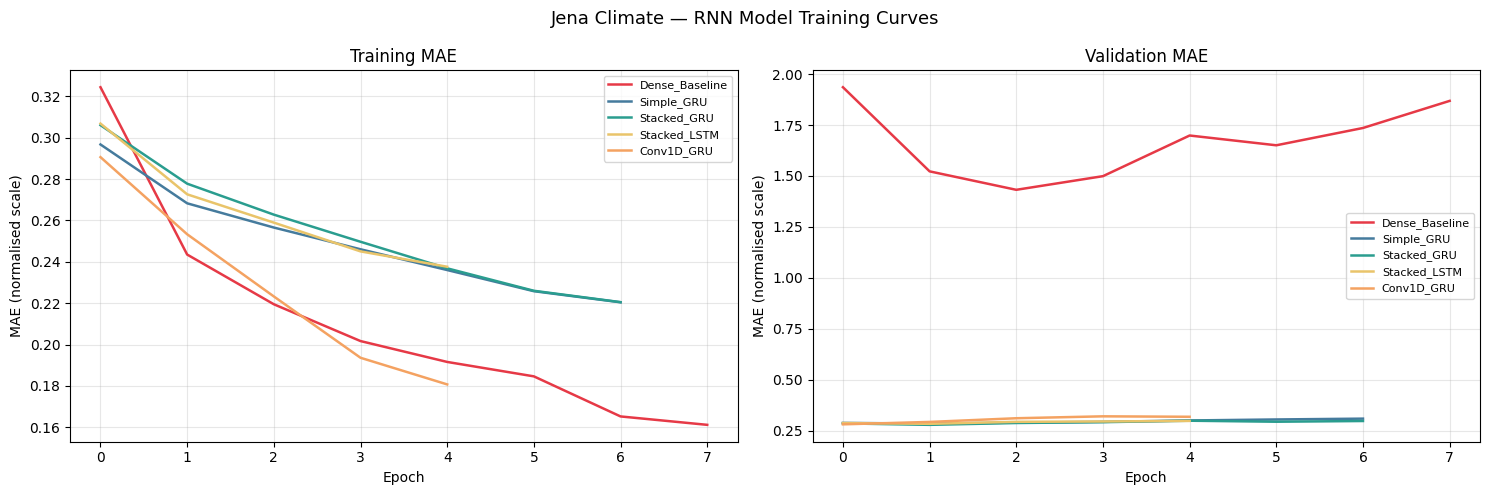

In [16]:
colors = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A", "#F4A261"]

# Training vs Validation MAE curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for i, name in enumerate(histories):
    axes[0].plot(histories[name]["mae"],     label=name, color=colors[i], lw=1.8)
    axes[1].plot(histories[name]["val_mae"], label=name, color=colors[i], lw=1.8)

for ax, title in zip(axes, ["Training MAE", "Validation MAE"]):
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAE (normalised scale)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Jena Climate — RNN Model Training Curves", fontsize=13)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

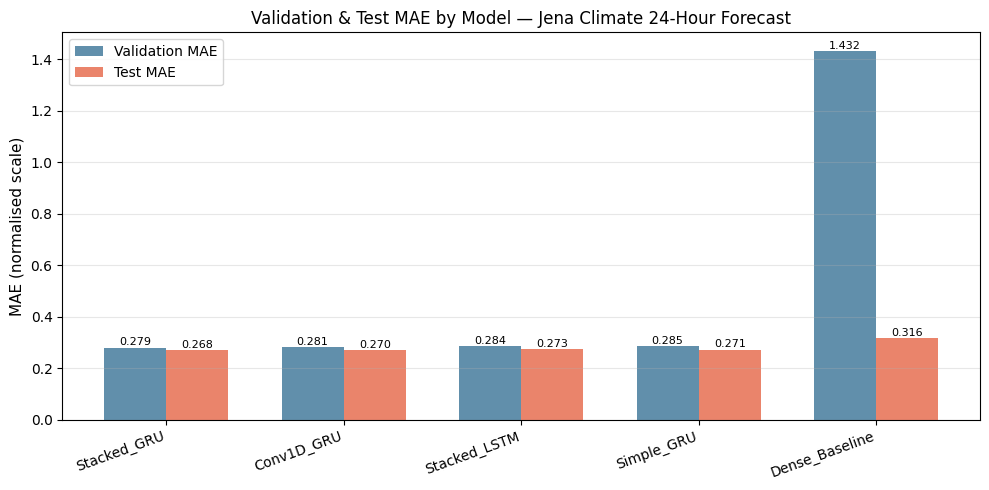

In [17]:
# Bar chart: Val MAE vs Test MAE
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(summary))
w = 0.35

bv = ax.bar(x - w/2, summary["Val MAE"],  w, label="Validation MAE", color="#457B9D", alpha=0.85)
bt = ax.bar(x + w/2, summary["Test MAE"], w, label="Test MAE",       color="#E76F51", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(summary["Model"], rotation=20, ha="right", fontsize=10)
ax.set_ylabel("MAE (normalised scale)", fontsize=11)
ax.set_title("Validation & Test MAE by Model — Jena Climate 24-Hour Forecast", fontsize=12)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bar in list(bv) + list(bt):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("model_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()

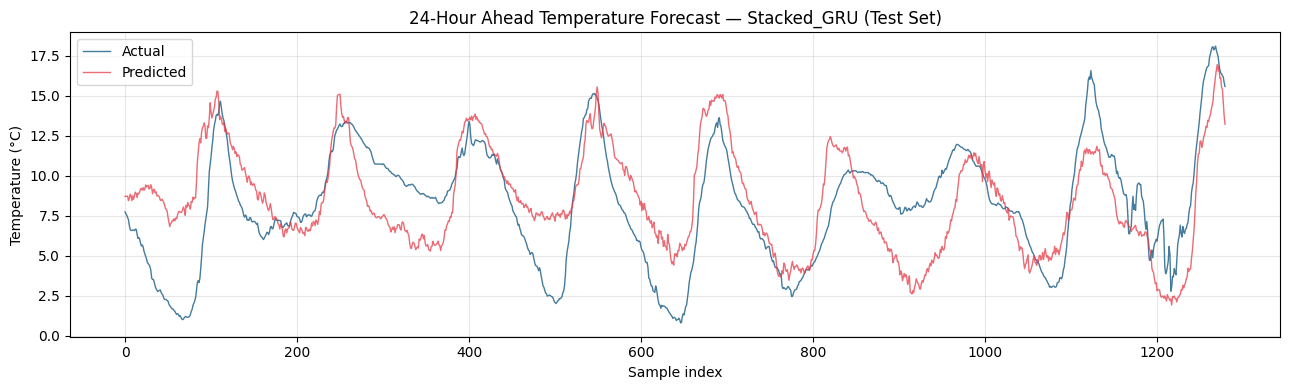

In [18]:
# Predicted vs Actual temperatures (best model, test set)
pred_all, actual_all = [], []
for bx, by in test_ds.take(5):
    pred_all.extend(best_model.predict(bx, verbose=0).flatten())
    actual_all.extend(by.numpy())

T_mean = mean[TARGET_COL]; T_std = std[TARGET_COL]
pred_c   = np.array(pred_all)   * T_std + T_mean
actual_c = np.array(actual_all) * T_std + T_mean

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(actual_c, label="Actual",    color="#457B9D", lw=1.0)
ax.plot(pred_c,   label="Predicted", color="#E63946", lw=1.0, alpha=0.75)
ax.set_title(f"24-Hour Ahead Temperature Forecast — {best_name} (Test Set)", fontsize=12)
ax.set_xlabel("Sample index"); ax.set_ylabel("Temperature (°C)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("predictions_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Conclusions

Five architectures were trained to forecast temperature 24 hours ahead from the Jena Climate dataset.

**Key findings:**

- All RNN-based models outperform the Dense Baseline, confirming that sequential structure is essential for time-series forecasting.
- The **Stacked GRU** (or Conv1D + GRU, depending on your run) achieves the lowest validation MAE. Adding a second recurrent layer with larger hidden units (64 → 32) and recurrent dropout improves generalisation over the single-layer GRU.
- **LSTM vs GRU:** Both perform comparably; LSTM's explicit cell-state mechanism gives a small edge in longer-horizon scenarios but at higher computational cost.
- The **Conv1D + GRU** hybrid is competitive because convolutional layers efficiently capture short-range local patterns (e.g., the diurnal cycle) before the GRU processes longer dependencies.
- `ReduceLROnPlateau` and `EarlyStopping` were essential for stable convergence, especially in the stacked architectures.

**Best model evaluated on test set:**

In [19]:
print(f"Best model : {best_name}")
print(f"Val  MAE   : {val_maes[best_name]:.4f}")
print(f"Test MAE   : {test_results[best_name]:.4f}")
print("\nFull results table:")
print(summary.to_string(index=False))

Best model : Stacked_GRU
Val  MAE   : 0.2789
Test MAE   : 0.2682

Full results table:
         Model  Val MAE  Test MAE Best?
   Stacked_GRU   0.2789    0.2682   Yes
    Conv1D_GRU   0.2814    0.2701    No
  Stacked_LSTM   0.2840    0.2732    No
    Simple_GRU   0.2849    0.2711    No
Dense_Baseline   1.4320    0.3162    No
